In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget

In [5]:
project_name = "syn"
condition = "demi_cycle_custom_124"
data = "biased_00"
switch_epoch = 0

checkpoint_epoch=0

n_samples = 32
show_results_fusion = False
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
samples = get_data_samples(data_module, n_samples, split ='train')

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/demi_cycle_custom_124_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/demi_cycle_custom_124_biased_00/checkpoints/last.ckpt


In [6]:
unimodal_latents = global_workspace.encode_domains(samples)
gw_latents = global_workspace.encode(unimodal_latents)

unimodal_decoded = global_workspace.decode(gw_latents[frozenset({'attr', 'v_latents'})])

a_from_v_decoded = split_softmax_category_attributes(unimodal_decoded["v_latents"]["attr"])
v_from_a_decoded = unimodal_decoded["attr"]["v_latents"]
demi_cycle_attr = unimodal_decoded["attr"]["attr"]
demi_cycle_v_latents = unimodal_decoded["v_latents"]["v_latents"]

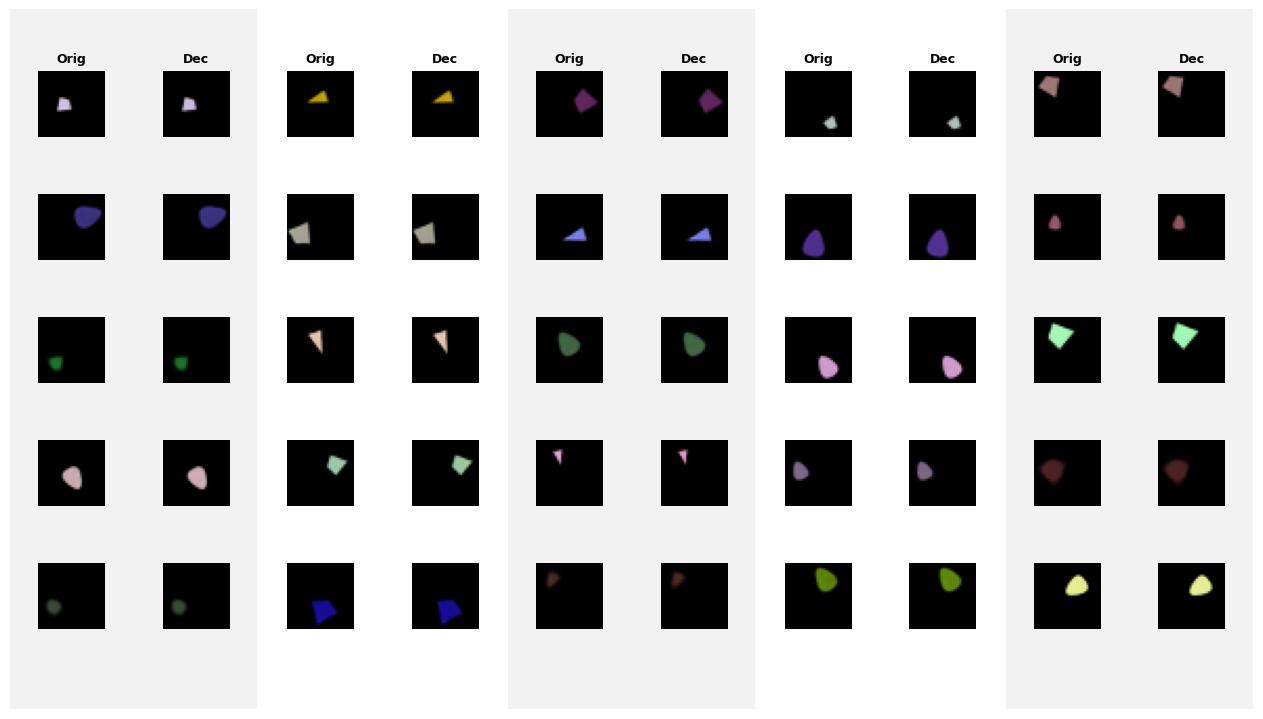

In [7]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])    

original_v_latents = samples[frozenset({'v_latents', 'attr'})]['v_latents']
original_images = visual_module.decode_images(original_v_latents).detach().cpu()
demi_cycle_images = visual_module.decode_images(demi_cycle_v_latents).detach().cpu()

fig = plot_img_comparison_triple_stripes(original_images, demi_cycle_images)
display(fig)

In [8]:
training_params

{'experiment_name': 'demi_cycle_custom_124_biased_00',
 'exclude_colors': True,
 'apply_custom_init': True,
 'config': Config(seed=124, ood_seed=None, default_root_dir=PosixPath('checkpoints'), dataset=Dataset(path='/home/lucas/gwsyn/simple_shapes_dataset_biased_00'), training=Training(batch_size=300, num_workers=16, devices=1, accelerator='gpu', fast_dev_run=False, max_steps=200000, enable_progress_bar=True, precision=32, float32_matmul_precision='highest', optim=Optim(lr=1e-05, max_lr=0.00015, start_lr=0.0001, end_lr=1e-05, pct_start=0.03, weight_decay=1e-06)), wandb=WanDB(enabled=True, save_dir='./wandb', project='Shimmer-SSD', entity='lexman-psl', reinit=False), logging=Logging(filter_images=['pred_trans_attr_to_attr', 'pred_trans_v_latents_to_v_latents', 'pred_trans_attr_to_v_latents', 'pred_trans_v_latents_to_attr', 'pred_cycle_v_latents_to_attr', 'pred_cycle_attr_to_v_latents', 'pred_cycle_v_latents_to_v_latents', 'pred_cycle_attr_to_attr'], log_train_medias_every_n_epochs=1, lo